# evaluation of the model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


In [37]:
# load the excel file, sheet of sum
df = pd.read_excel('/Users/junjiezhang/Documents/GitHub/FDA_ChatBot/rating for Chatbot answers.xlsx', sheet_name='sum')

In [38]:
df.head()
# change the type of question to string
df['question'] = df['question'].astype(str)
print(df.columns)

Index(['question', 'answer by RAG', 'Accuracy  ', 'Relevancy', 'Fluency ',
       'Overall', 'Cos similarity'],
      dtype='object')


In [41]:
# remove the "" in the column names
df.columns = df.columns.str.replace(' ', '')
print(df.columns)
df.head()


Index(['question', 'answerbyRAG', 'Accuracy', 'Relevancy', 'Fluency',
       'manual_overall', 'Cossimilarity'],
      dtype='object')


,question,answerbyRAG,Accuracy,Relevancy,Fluency,manual_overall,Cossimilarity
0,1,No,4,5,4,13,0.864
1,1,Yes,5,5,5,15,0.863
2,2,No,3,5,3,11,0.620
3,2,Yes,5,5,5,15,0.634
4,3,No,5,4,5,14,0.962


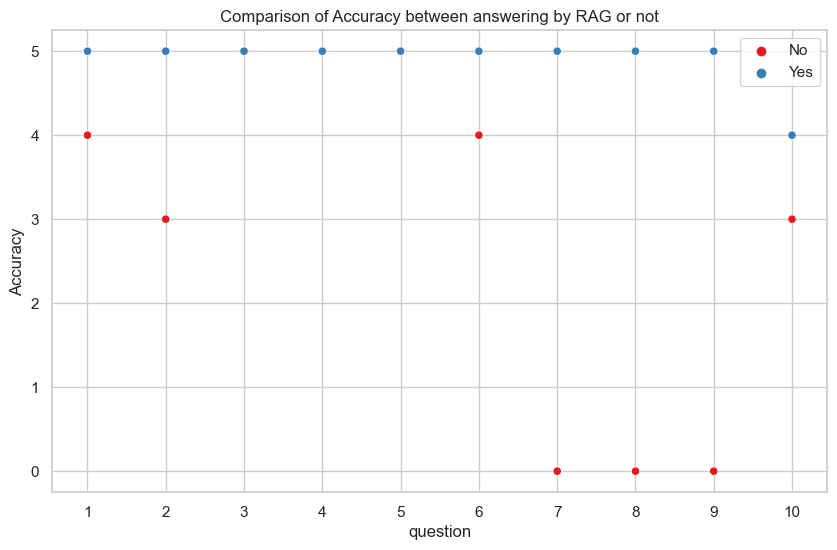

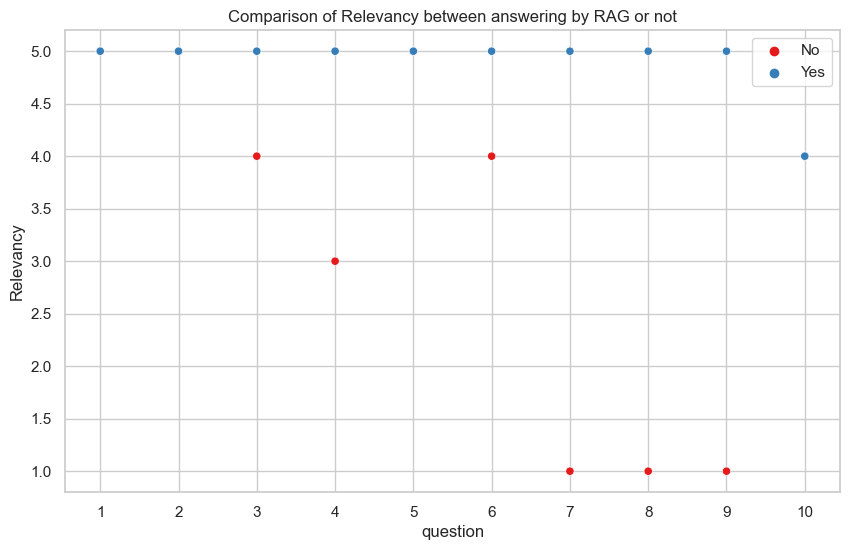

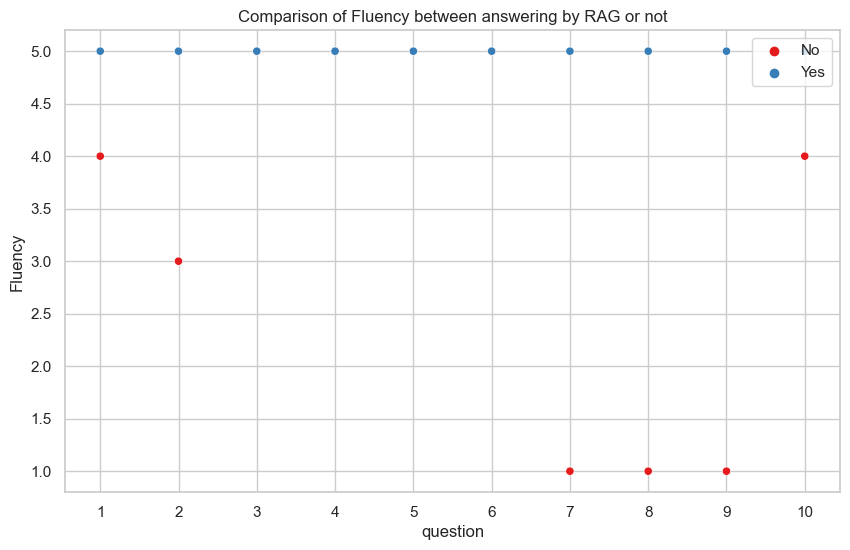

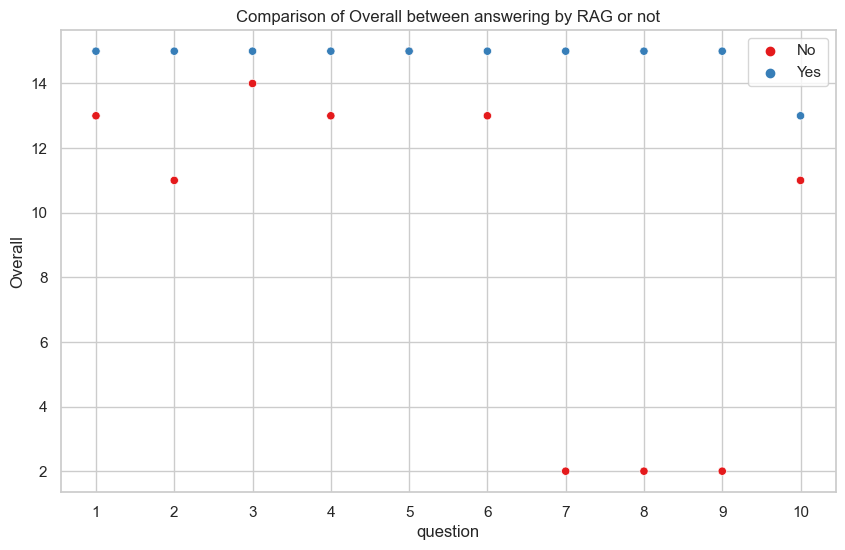

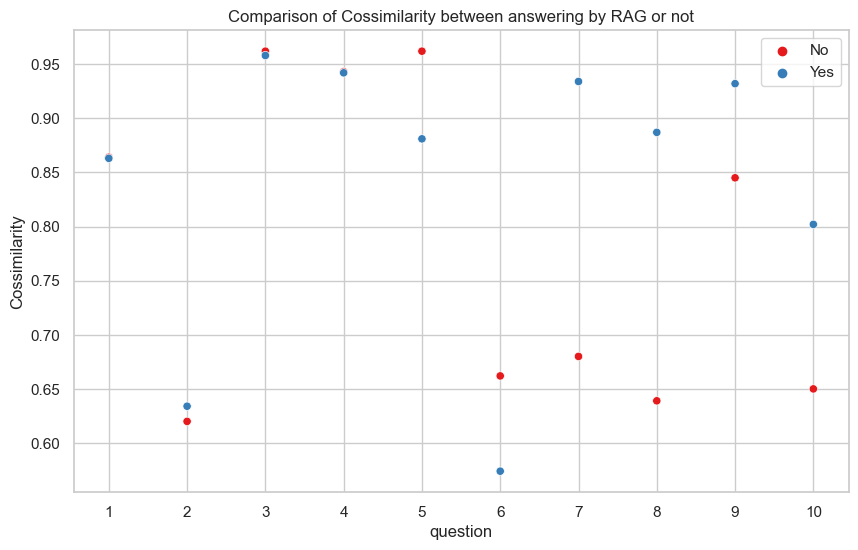

In [32]:
# for each question, plot the 'Accuracy', 'Relevancy', 'Fluency ', 'Overall', 'Cos similarity' between 'answerbyRAG' (yes vs no)
# label the legend as 'RAG', 'no_RAG'


for i in ['Accuracy', 'Relevancy', 'Fluency', 'Overall', 'Cossimilarity']:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='question', y=i, hue='answerbyRAG', data=df, palette='Set1')
    plt.title('Comparison of ' + i + ' between answering by RAG or not')
    plt.legend(loc='upper right')
    plt.show()



In [42]:
# calculate the average of 'Overall', 'Cos similarity' for each group of 'answerbyRAG'
# change the col Overall to 'manual_overall'
df.rename(columns={'Overall': 'manual_overall'}, inplace=True)
df.groupby('answerbyRAG')['manual_overall', 'Cossimilarity'].mean()




,manual_overall,Cossimilarity
answerbyRAG,,
No,9.6,0.7827
Yes,14.8,0.8407
